# Tercer parcial – Sistemas Inteligentes II

Estudiante: Daniela Agudelo Martínez  
Curso: Sistemas Inteligentes II  

En este notebook desarrollo los tres puntos del parcial usando el repositorio UCI:

1. Clasificación con CART sobre Mushroom y Car Evaluation: reglas, validación cruzada, poda y comparación entre datasets.
2. Clustering jerárquico sobre Wholesale Customers: dendrogramas, linkages (single, complete, average, ward), cortes y métricas internas.
3. Regresión sobre Real Estate Valuation: comparación entre K-NN, ε-SVR y red neuronal (MLPRegressor).


## Configuración

Configuración del entorno, instalación e importación de librerías


In [1]:
import sys
print(sys.executable)

!{sys.executable} -m pip install -q ucimlrepo scipy seaborn scikit-learn pandas numpy matplotlib

C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_validate,
    GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## Punto 1: CART en clasificación

Selecciono Mushroom (UCI id=73) y Car Evaluation (id=19). Construyo árboles CART, extraigo reglas, valido con holdout y validación cruzada estratificada, aplico poda con GridSearchCV y comparo ambos datasets.

- Holdout: 80 % entrenamiento / 20 % prueba (una partición fija).
- CV: 5 folds estratificados para estimar desempeño promedio.


## CART y clasificación con hongos (Mushroom, UCI id=73)

### Contexto del dataset

El dataset describe hongos con variables morfológicas (olor, forma del sombrero, color, etc.). El objetivo es predecir si son comestibles (e) o venenosos (p). Todas las variables son categóricas, por lo que se espera reglas legibles en el árbol.

### Qué analizo

1. Qué atributos separan mejor las dos clases.
2. Qué reglas explícitas produce el árbol (pureza, cobertura, profundidad).
3. Si el modelo generaliza en holdout y en validación cruzada.

### CART 

- Nodo / rama / hoja: preguntas en la raíz, condiciones en ramas, clase en hojas.
- Pureza (Gini): qué tan mezcladas están las clases en cada nodo.
- Pipeline: OneHotEncoder + árbol para codificar categorías sin fuga entre train y test.


In [7]:
# Carga de Mushroom
mushroom = fetch_ucirepo(id=73)
X_mush = mushroom.data.features.copy()
y_mush = mushroom.data.targets.copy()

# Asegurar vector objetivo 1D
if isinstance(y_mush, pd.DataFrame):
    y_mush = y_mush.iloc[:, 0]

df_mush = X_mush.copy()
df_mush['target'] = y_mush

print('Shape X:', X_mush.shape)
print('Clases target:', y_mush.value_counts())
print('\nTipos de variables:')
print(X_mush.dtypes.value_counts())

# Detectar columnas categóricas
cat_cols = X_mush.columns.tolist()

# Pipeline CART para variables categóricas
cart_base = Pipeline(steps=[
    ('prep', ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)]
    )),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Split holdout para inspección de reglas y matriz de confusión
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mush, y_mush,
    test_size=0.2,
    stratify=y_mush,
    random_state=RANDOM_STATE
)

cart_base.fit(X_train_m, y_train_m)
y_pred_base = cart_base.predict(X_test_m)

print('\n=== Modelo base (holdout) ===')
print('Accuracy:', accuracy_score(y_test_m, y_pred_base))
print('F1 macro:', f1_score(y_test_m, y_pred_base, average='macro'))
print('\nReporte de clasificación:')
print(classification_report(y_test_m, y_pred_base))

Shape X: (8124, 22)
Clases target: poisonous
e    4208
p    3916
Name: count, dtype: int64

Tipos de variables:
object    22
Name: count, dtype: int64

=== Modelo base (holdout) ===
Accuracy: 1.0
F1 macro: 1.0

Reporte de clasificación:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### Validación cruzada estratificada

Antes usé un holdout del 20 % (partición fija train/test). Aquí aplico validación cruzada con 5 folds estratificados (StratifiedKFold), manteniendo la proporción de clases e y p en cada fold.

Reporto accuracy, precisión, recall y F1 macro (promedio del F1 por clase). Así estimo la generalización sin depender solo del holdout.


In [74]:
# Validación cruzada del CART base
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_cls = {
    'acc': 'accuracy',
    'prec_macro': 'precision_macro',
    'rec_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_base = cross_validate(
    cart_base,
    X_mush,
    y_mush,
    cv=cv_strat,
    scoring=scoring_cls,
    n_jobs=-1,
    return_train_score=True
)

print('=== CV CART base (5-fold) ===')
for m in ['acc', 'prec_macro', 'rec_macro', 'f1_macro']:
    arr = cv_base[f'test_{m}']
    print(f'{m}: {arr.mean():.4f} ± {arr.std():.4f}')

=== CV CART base (5-fold) ===
acc: 1.0000 ± 0.0000
prec_macro: 1.0000 ± 0.0000
rec_macro: 1.0000 ± 0.0000
f1_macro: 1.0000 ± 0.0000


### Poda y ajuste de hiperparámetros

Ajusto el árbol con GridSearchCV sobre la misma CV estratificada, buscando equilibrio entre interpretabilidad y generalización:

- max_depth: limita la profundidad del árbol.
- min_samples_leaf: evita hojas con muy pocas muestras (posible sobreajuste).
- ccp_alpha: poda por complejidad de costo (cost-complexity pruning).

Comparo métricas en holdout entre el CART base y el CART ajustado para mirar si la poda reduce complejidad sin perder demasiado desempeño.


In [75]:
# Ajuste de hiperparámetros / poda
param_grid_cart = {
    'model__max_depth': [None, 3, 5, 8, 12],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__ccp_alpha': [0.0, 1e-4, 1e-3, 1e-2]
}

grid_cart = GridSearchCV(
    estimator=cart_base,
    param_grid=param_grid_cart,
    scoring='f1_macro',
    cv=cv_strat,
    n_jobs=-1,
    refit=True
)

grid_cart.fit(X_train_m, y_train_m)
best_cart = grid_cart.best_estimator_
y_pred_best = best_cart.predict(X_test_m)

print('=== Mejor CART (GridSearchCV) ===')
print('Mejores parámetros:', grid_cart.best_params_)
print('Mejor F1_macro CV interno:', grid_cart.best_score_)
print('Accuracy holdout:', accuracy_score(y_test_m, y_pred_best))
print('F1 macro holdout:', f1_score(y_test_m, y_pred_best, average='macro'))

# Comparación base vs podado en el mismo holdout
comp_cls = pd.DataFrame({
    'Modelo': ['CART base', 'CART ajustado/podado'],
    'Accuracy': [accuracy_score(y_test_m, y_pred_base), accuracy_score(y_test_m, y_pred_best)],
    'F1_macro': [f1_score(y_test_m, y_pred_base, average='macro'), f1_score(y_test_m, y_pred_best, average='macro')]
})
print('\nComparación holdout:')
print(comp_cls)

=== Mejor CART (GridSearchCV) ===
Mejores parámetros: {'model__ccp_alpha': 0.0, 'model__max_depth': None, 'model__min_samples_leaf': 1}
Mejor F1_macro CV interno: 0.9996918876385321
Accuracy holdout: 1.0
F1 macro holdout: 1.0

Comparación holdout:
                 Modelo  Accuracy  F1_macro
0             CART base       1.0       1.0
1  CART ajustado/podado       1.0       1.0


### Reglas, estructura del árbol e interpretación

Extraigo reglas con export_text, con un gráfico del árbol y con tablas de nodos internos.

Para clasificar una regla como más relevante uso:

| Criterio | Qué mido |
|----------|----------|
| Pureza | Fracción de la hoja (o rama) que pertenece a una sola clase |
| Cobertura | % de muestras de entrenamiento que pasan por esa regla |
| Profundidad | Número de condiciones desde la raíz (menos profundidad → regla más simple) |

En el resultado, la raíz pregunta por olor (odor): el 100 % de los datos pasa por ese nodo. Las ramas inmediatas concentran casi solo comestibles o casi solo venenosos, con pureza alta; por eso la considero la regla principal del árbol.


Profundidad del árbol: 7
Número de hojas: 14
=== Reglas (primeros niveles) ===
|--- cat__odor_n <= 0.50
|   |--- cat__stalk-root_c <= 0.50
|   |   |--- cat__stalk-surface-below-ring_y <= 0.50
|   |   |   |--- cat__odor_a <= 0.50
|   |   |   |   |--- cat__odor_l <= 0.50
|   |   |   |   |   |--- class: p
|   |   |   |   |--- cat__odor_l >  0.50
|   |   |   |   |   |--- class: e
|   |   |   |--- cat__odor_a >  0.50
|   |   |   |   |--- class: e
|   |   |--- cat__stalk-surface-below-ring_y >  0.50
|   |   |   |--- class: e
|   |--- cat__stalk-root_c >  0.50
|   |   |--- cat__bruises_t <= 0.50
|   |   |   |--- class: p
|   |   |--- cat__bruises_t >  0.50
|   |   |   |--- class: e
|--- cat__odor_n >  0.50
|   |--- cat__spore-print-color_r <= 0.50
|   |   |--- cat__stalk-surface-below-ring_y <= 0.50
|   |   |   |--- cat__cap-surface_g <= 0.50
|   |   |   |   |--- cat__cap-shape_c <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- cat__cap-shape_c >  0.50
|   |  

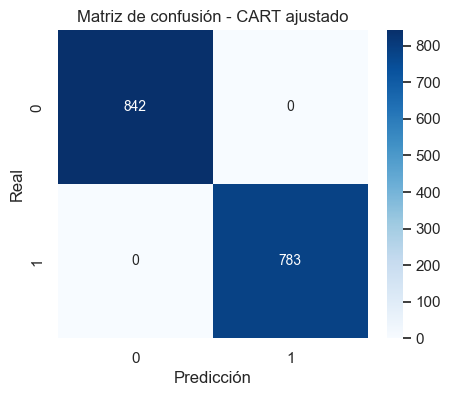

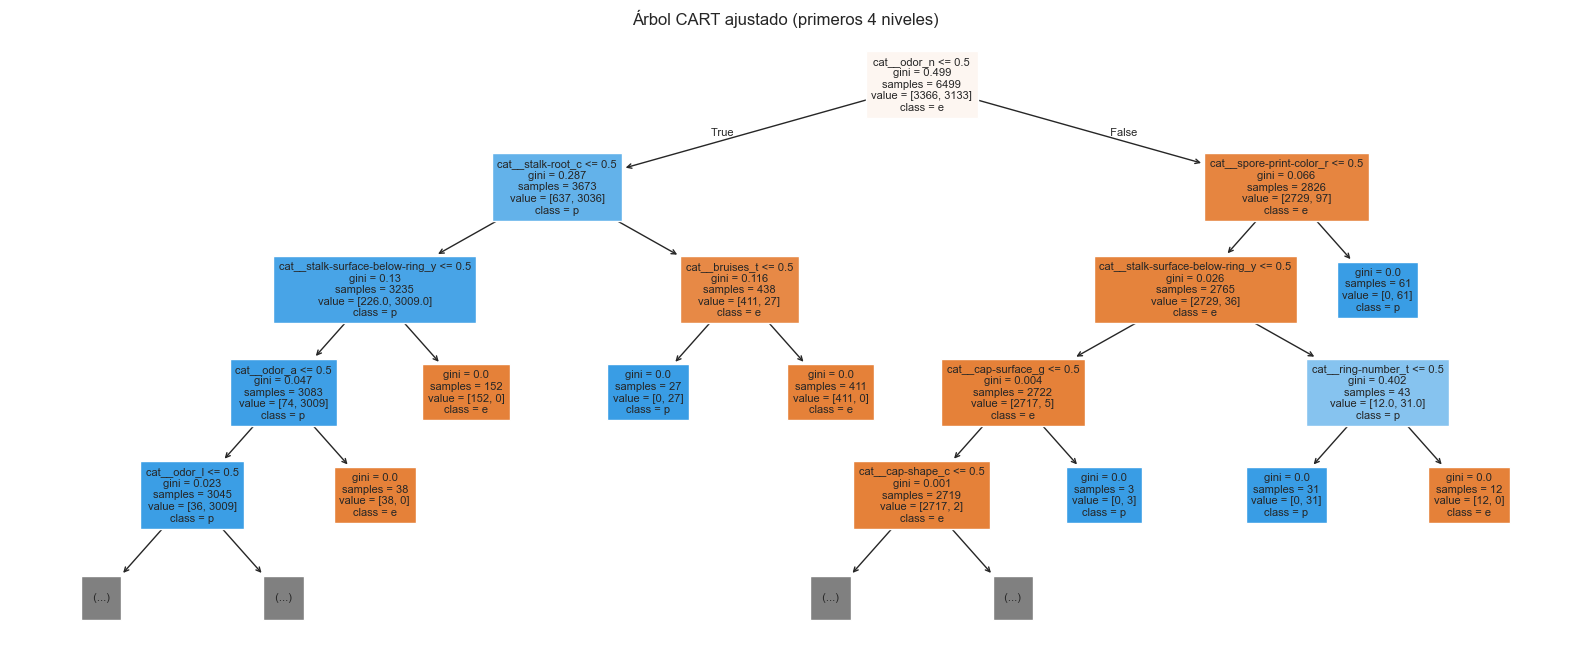

=== Nodos internos del árbol ===
 profundidad                     pregunta  muestras  cobertura_% rama_izq_predomina  pureza_izq rama_der_predomina  pureza_der
           0                     odor = n      6499        100.0                  p       0.827                  e       0.966
           1               stalk-root = c      3673         56.5                  p       0.930                  e       0.938
           2 stalk-surface-below-ring = y      3235         49.8                  p       0.976                  e       1.000
           3                     odor = a      3083         47.4                  p       0.988                  e       1.000
           2                  bruises = t       438          6.7                  p       1.000                  e       1.000
           1        spore-print-color = r      2826         43.5                  e       0.987                  p       1.000
           2 stalk-surface-below-ring = y      2765         42.5              

In [77]:
# Estructura del árbol, reglas y visualizaciones
preprocessor = best_cart.named_steps['prep']
tree_model = best_cart.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

print('Profundidad del árbol:', tree_model.get_depth())
print('Número de hojas:', tree_model.get_n_leaves())

# Reglas explícitas (texto)
rules_text = export_text(tree_model, feature_names=list(feature_names), max_depth=4)
print('=== Reglas (primeros niveles) ===')
print(rules_text)

# Matriz de confusión
cm = confusion_matrix(y_test_m, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - CART ajustado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Dibujo parcial del árbol para legibilidad
plt.figure(figsize=(20, 8))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(y_mush.unique())],
    filled=True,
    max_depth=4,
    fontsize=8
)
plt.title('Árbol CART ajustado (primeros 4 niveles)')
plt.show()

# --- Reglas: nodos internos vs hojas (tablas separadas, sin NaN) ---
from sklearn.tree import _tree

def _nombre_legible(feat_name):
    """Convierte cat__odor_n -> olor = n (categoría one-hot)."""
    if feat_name is None:
        return "?"
    s = str(feat_name)
    if s.startswith("cat__"):
        s = s[5:]
    if "_" in s:
        var, cat = s.rsplit("_", 1)
        return f"{var} = {cat}"
    return s

def analizar_reglas_arbol(clf, feature_names, class_names, max_prof_nodos=3,
                          min_muestras_hoja=30, top_hojas=8):
  t = clf.tree_
  n_train = int(t.n_node_samples[0])
  nodos, hojas = [], []

  def clase_pred(values):
    idx = int(values.argmax())
    total = values.sum()
    return class_names[idx], float(values.max() / total), int(total)

  def recorrer(nodo, prof, conds):
    if t.feature[nodo] != _tree.TREE_UNDEFINED:
      feat = feature_names[t.feature[nodo]]
      thr = t.threshold[nodo]
      n = int(t.n_node_samples[nodo])
      izq_c, izq_p, _ = clase_pred(t.value[t.children_left[nodo]][0])
      der_c, der_p, _ = clase_pred(t.value[t.children_right[nodo]][0])
      nodos.append({
        "profundidad": prof,
        "pregunta": _nombre_legible(feat),
        "muestras": n,
        "cobertura_%": round(100 * n / n_train, 1),
        "rama_izq_predomina": izq_c,
        "pureza_izq": round(izq_p, 3),
        "rama_der_predomina": der_c,
        "pureza_der": round(der_p, 3),
      })
      recorrer(t.children_left[nodo], prof + 1, conds + [f"{_nombre_legible(feat)} <= {thr:.2f}"])
      recorrer(t.children_right[nodo], prof + 1, conds + [f"{_nombre_legible(feat)} > {thr:.2f}"])
    else:
      clase, pur, n = clase_pred(t.value[nodo][0])
      hojas.append({
        "profundidad": prof,
        "muestras": n,
        "cobertura_%": round(100 * n / n_train, 1),
        "clase_predicha": clase,
        "pureza": round(pur, 3),
        "regla_si_entonces": " SI ".join(conds) + f" → {clase}" if conds else f"→ {clase}",
      })

  recorrer(0, 0, [])
  df_nodos = pd.DataFrame(nodos)
  df_hojas = pd.DataFrame(hojas)

  print("=== Nodos internos del árbol ===")
  print(df_nodos[df_nodos["profundidad"] <= max_prof_nodos].to_string(index=False))

  df_utiles = df_hojas[df_hojas["muestras"] >= min_muestras_hoja].copy()
  df_utiles["prioridad"] = df_utiles["pureza"] * (df_utiles["cobertura_%"] / 100) / (1 + df_utiles["profundidad"])
  df_utiles = df_utiles.sort_values("prioridad", ascending=False)

  return df_nodos, df_hojas

class_names_m = [str(c) for c in sorted(y_mush.unique())]
nodos_m, hojas_m = analizar_reglas_arbol(tree_model, feature_names, class_names_m)


### Conclusión – Mushroom

Resultados

- 8124 muestras, 22 atributos categóricos; clases balanceadas (e: 4208, p: 3916).
- Holdout: accuracy y F1 macro = 1.00 (sin errores en el 20 % de prueba).
- CV 5-fold: 1.00 ± 0.00 en accuracy y F1 macro.
- Árbol ajustado: profundidad 7, 14 hojas; variable raíz: olor (odor).
- Poda: ccp_alpha = 0; modelo base y ajustado iguales en holdout.

Reglas e interpretabilidad

En la tabla de nodos internos, la raíz pregunta por olor = n (cobertura 100 %). En la rama izquierda predomina p (pureza ≈ 0.83) y en la derecha e (pureza ≈ 0.97): es la regla más relevante por cobertura y pureza en el primer nivel. Las reglas más profundas refinan casos concretos.

Conclusión

Con estas variables el problema es casi determinístico. Comparo con Car Evaluation para ver un escenario con más error y varias clases.


### Segundo dataset: Car Evaluation (UCI, id=19)

Contexto

Valoración de autos según precio, mantenimiento, puertas, personas, maletero y seguridad. Se predice aceptabilidad: unacc, acc, good, vgood.

Hay cuatro clases y fuerte desbalance (pocas muestras en good y vgood). Repito el mismo flujo: pipeline, holdout, CV y extracción de reglas.


=== Car Evaluation ===
Shape X: (1728, 6)
Clases target:
 class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

=== Modelo base Car (holdout) ===
Accuracy: 0.9739884393063584
F1 macro: 0.945032602635408

=== CV CART base Car (5-fold) ===
acc: 0.9676 ± 0.0091
prec_macro: 0.9381 ± 0.0366
rec_macro: 0.9175 ± 0.0503
f1_macro: 0.9244 ± 0.0442

=== Mejor CART Car (GridSearchCV) ===
Mejores parámetros: {'model__ccp_alpha': 0.0, 'model__max_depth': None, 'model__min_samples_leaf': 1}
Accuracy holdout: 0.9739884393063584
F1 macro holdout: 0.945032602635408

Comparación holdout Car:
                 Modelo  Accuracy  F1_macro
0             CART base  0.973988  0.945033
1  CART ajustado/podado  0.973988  0.945033

Profundidad árbol Car: 14
Hojas árbol Car: 101
=== Reglas Car (primeros niveles) ===
|--- cat__safety_low <= 0.50
|   |--- cat__persons_2 <= 0.50
|   |   |--- cat__buying_vhigh <= 0.50
|   |   |   |--- cat__buying_high <= 0.50
|   |   |   |   |--- cat_

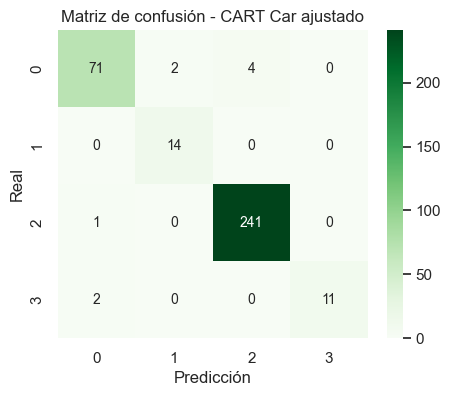

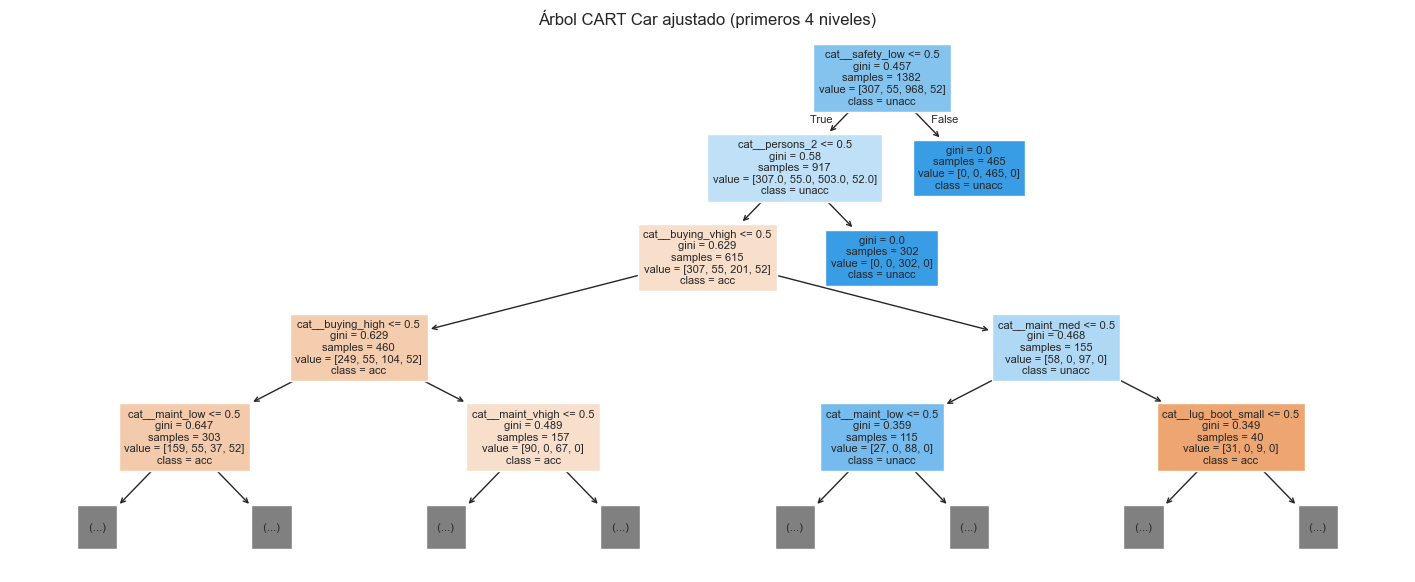

=== Car Evaluation: nodos y hojas ===
=== Nodos internos del árbol ===
 profundidad       pregunta  muestras  cobertura_% rama_izq_predomina  pureza_izq rama_der_predomina  pureza_der
           0   safety = low      1382        100.0              unacc       0.549              unacc       1.000
           1    persons = 2       917         66.4                acc       0.499              unacc       1.000
           2 buying = vhigh       615         44.5                acc       0.541              unacc       0.626
           3  buying = high       460         33.3                acc       0.525                acc       0.573
           3    maint = med       155         11.2              unacc       0.765                acc       0.775


(    profundidad        pregunta  muestras  cobertura_% rama_izq_predomina  \
 0             0    safety = low      1382        100.0              unacc   
 1             1     persons = 2       917         66.4                acc   
 2             2  buying = vhigh       615         44.5                acc   
 3             3   buying = high       460         33.3                acc   
 4             4     maint = low       303         21.9                acc   
 ..          ...             ...       ...          ...                ...   
 95            9     persons = 4         2          0.1                acc   
 96            7    safety = med         2          0.1                acc   
 97            5    safety = med        13          0.9                acc   
 98            6       doors = 2         7          0.5                acc   
 99            7  persons = more         2          0.1                acc   
 
     pureza_izq rama_der_predomina  pureza_der  
 0        0.5

In [78]:
# Car Evaluation (UCI id=19) 
car = fetch_ucirepo(id=19)
X_car = car.data.features.copy()
y_car = car.data.targets.copy()
if isinstance(y_car, pd.DataFrame):
    y_car = y_car.iloc[:, 0]

print('=== Car Evaluation ===')
print('Shape X:', X_car.shape)
print('Clases target:\n', y_car.value_counts())

cat_cols_car = X_car.columns.tolist()

cart_car_base = Pipeline(steps=[
    ('prep', ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_car)]
    )),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_car, y_car, test_size=0.2, stratify=y_car, random_state=RANDOM_STATE
)

cart_car_base.fit(X_train_c, y_train_c)
y_pred_car_base = cart_car_base.predict(X_test_c)

print('\n=== Modelo base Car (holdout) ===')
print('Accuracy:', accuracy_score(y_test_c, y_pred_car_base))
print('F1 macro:', f1_score(y_test_c, y_pred_car_base, average='macro'))

# CV del modelo base (reutiliza cv_strat y scoring_cls definidos en Mushroom)
cv_car_base = cross_validate(
    cart_car_base, X_car, y_car, cv=cv_strat, scoring=scoring_cls,
    n_jobs=-1, return_train_score=True
)
print('\n=== CV CART base Car (5-fold) ===')
for m in ['acc', 'prec_macro', 'rec_macro', 'f1_macro']:
    arr = cv_car_base[f'test_{m}']
    print(f'{m}: {arr.mean():.4f} ± {arr.std():.4f}')

# Ajuste / poda (reutiliza param_grid_cart)
grid_car = GridSearchCV(
    estimator=cart_car_base,
    param_grid=param_grid_cart,
    scoring='f1_macro',
    cv=cv_strat,
    n_jobs=-1,
    refit=True
)
grid_car.fit(X_train_c, y_train_c)
best_cart_car = grid_car.best_estimator_
y_pred_car_best = best_cart_car.predict(X_test_c)

print('\n=== Mejor CART Car (GridSearchCV) ===')
print('Mejores parámetros:', grid_car.best_params_)
print('Accuracy holdout:', accuracy_score(y_test_c, y_pred_car_best))
print('F1 macro holdout:', f1_score(y_test_c, y_pred_car_best, average='macro'))

comp_car = pd.DataFrame({
    'Modelo': ['CART base', 'CART ajustado/podado'],
    'Accuracy': [
        accuracy_score(y_test_c, y_pred_car_base),
        accuracy_score(y_test_c, y_pred_car_best)
    ],
    'F1_macro': [
        f1_score(y_test_c, y_pred_car_base, average='macro'),
        f1_score(y_test_c, y_pred_car_best, average='macro')
    ]
})
print('\nComparación holdout Car:')
print(comp_car)

# Reglas y visualización del árbol ajustado
prep_car = best_cart_car.named_steps['prep']
tree_car = best_cart_car.named_steps['model']
feat_car = prep_car.get_feature_names_out()

print('\nProfundidad árbol Car:', tree_car.get_depth())
print('Hojas árbol Car:', tree_car.get_n_leaves())
print('=== Reglas Car (primeros niveles) ===')
print(export_text(tree_car, feature_names=list(feat_car), max_depth=4))

cm_car = confusion_matrix(y_test_c, y_pred_car_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_car, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - CART Car ajustado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

plt.figure(figsize=(18, 7))
plot_tree(
    tree_car, feature_names=feat_car,
    class_names=[str(c) for c in sorted(y_car.unique())],
    filled=True, max_depth=4, fontsize=8
)
plt.title('Árbol CART Car ajustado (primeros 4 niveles)')
plt.show()

# Reglas Car (mismas tablas: nodos vs hojas)
class_names_c = [str(c) for c in sorted(y_car.unique())]
print("=== Car Evaluation: nodos y hojas ===")
analizar_reglas_arbol(tree_car, feat_car, class_names_c, min_muestras_hoja=20, top_hojas=8)

### Conclusión – Car Evaluation

Resultados

- 1728 autos; holdout: accuracy 0.974, F1 macro 0.945.
- CV: accuracy 0.9676 ± 0.0091, F1 macro 0.9244 ± 0.0442.
- Árbol: profundidad 14, 101 hojas; primera pregunta: seguridad (safety).

Reglas

Cuando seguridad es baja (safety_low), una rama lleva directamente a inaceptable (unacc). El resto del árbol combina precio, personas, mantenimiento, etc. Las clases good y vgood son minoritarias (69 y 65 muestras), por eso el F1 macro (0.945) queda por debajo del accuracy (0.974).

Conclusión

CART sigue siendo interpretable, pero el árbol es mucho más largo que en Mushroom y el desbalance hace más difícil acertar en las clases raras.

### Comparación Mushroom vs Car Evaluation

Defino una función evaluate_cart que resume el mismo flujo (holdout base vs ajustado, CV del modelo base y complejidad del árbol podado) para ambos datasets

Con esta tabla y las gráficas comparo generalización, accuracy y complejidad (profundidad y hojas) entre dominios.


In [79]:
# Comparación Mushroom vs Car – evaluate_cart


def evaluate_cart(X, y, name):
    # Resume holdout base vs ajustado, CV del base y complejidad del arbol podado
    cat_cols_local = X.columns.tolist()
    pipe = Pipeline(steps=[
        ('prep', ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_local)
        ])),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    pipe.fit(X_train, y_train)
    y_pred_base = pipe.predict(X_test)
    cv_res = cross_validate(
        pipe, X, y, cv=cv_strat,
        scoring={'acc': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=-1
    )
    gs = GridSearchCV(
        pipe, param_grid=param_grid_cart, scoring='f1_macro',
        cv=cv_strat, n_jobs=-1, refit=True
    )
    gs.fit(X_train, y_train)
    best_pipe = gs.best_estimator_
    y_pred_best = best_pipe.predict(X_test)
    tree = best_pipe.named_steps['model']
    return {
        'Dataset': name,
        'N_muestras': len(X),
        'N_features': X.shape[1],
        'N_clases': y.nunique(),
        'CV_Accuracy_base_mean': cv_res['test_acc'].mean(),
        'CV_Accuracy_base_std': cv_res['test_acc'].std(),
        'CV_F1_macro_base_mean': cv_res['test_f1_macro'].mean(),
        'Holdout_Accuracy_base': accuracy_score(y_test, y_pred_base),
        'Holdout_Accuracy_ajustado': accuracy_score(y_test, y_pred_best),
        'Holdout_F1_macro_ajustado': f1_score(y_test, y_pred_best, average='macro'),
        'Depth_arbol_ajustado': tree.get_depth(),
        'Hojas_arbol_ajustado': tree.get_n_leaves(),
        'Best_params': gs.best_params_
    }


res_mush_vs_car = pd.DataFrame([
    evaluate_cart(X_mush, y_mush, 'Mushroom'),
    evaluate_cart(X_car, y_car, 'Car Evaluation'),
])
res_mush_vs_car


,Dataset,N_muestras,N_features,N_clases,CV_Accuracy_base_mean,CV_Accuracy_base_std,CV_F1_macro_base_mean,Holdout_Accuracy_base,Holdout_Accuracy_ajustado,Holdout_F1_macro_ajustado,Depth_arbol_ajustado,Hojas_arbol_ajustado,Best_params
0,Mushroom,8124,22,2,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,7,14,"{'model__ccp_alpha': 0.0, 'model__max_depth': ..."
1,Car Evaluation,1728,6,4,0.967588,0.009068,0.924437,0.973988,0.973988,0.945033,14,101,"{'model__ccp_alpha': 0.0, 'model__max_depth': ..."


          Dataset  Holdout_Accuracy_base  Holdout_Accuracy_ajustado  \
0        Mushroom               1.000000                   1.000000   
1  Car Evaluation               0.973988                   0.973988   

   Depth_arbol_ajustado  Hojas_arbol_ajustado  
0                     7                    14  
1                    14                   101  


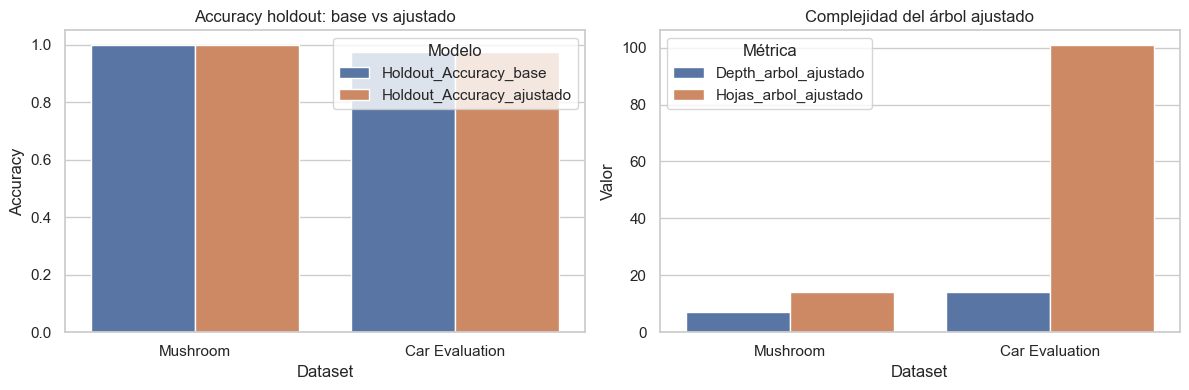

In [80]:
# Visualización rápida de la comparación Mushroom vs Car
plot_comp = res_mush_vs_car[['Dataset', 'Holdout_Accuracy_base', 'Holdout_Accuracy_ajustado', 'Depth_arbol_ajustado', 'Hojas_arbol_ajustado']].copy()
print(plot_comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_comp.melt(id_vars='Dataset', value_vars=['Holdout_Accuracy_base', 'Holdout_Accuracy_ajustado']),
            x='Dataset', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Accuracy holdout: base vs ajustado')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].legend(title='Modelo')

sns.barplot(data=plot_comp.melt(id_vars='Dataset', value_vars=['Depth_arbol_ajustado', 'Hojas_arbol_ajustado']),
            x='Dataset', y='value', hue='variable', ax=axes[1])
axes[1].set_title('Complejidad del árbol ajustado')
axes[1].set_ylabel('Valor')
axes[1].legend(title='Métrica')

plt.tight_layout()
plt.show()

### Conclusión general del Punto 1

| Aspecto | Mushroom | Car Evaluation |
|--------|----------|----------------|
| CV accuracy (base) | 1.0000 | 0.9676 |
| Holdout accuracy (ajustado) | 1.0000 | 0.9740 |
| Holdout F1 macro (ajustado) | 1.0000 | 0.9450 |
| Profundidad | 7 | 14 |
| Hojas | 14 | 101 |
| Variable raíz | Olor | Seguridad |

En ambos datasets obtuve reglas con export_text y tablas de nodos; las más relevantes están en el primer nivel (máxima cobertura). La poda no cambió el resultado (ccp_alpha = 0). Mushroom separa casi sin error; Car es más realista (4 clases, desbalance, árbol más profundo).

## Punto 2: Clustering jerárquico

### Contexto del dataset — Wholesale Customers (UCI, id=292)

- Gasto anual en productos (frescos, lácteos, comestibles, etc.) de clientes mayoristas en Portugal.
- No hay etiqueta de clase, queremos descubrir grupos de clientes con perfiles de gasto parecidos.
- La idea es entender: ¿cuántos grupos naturales hay (k)? ¿Qué linkage (single, complete, average, ward) describe mejor la estructura?

### Se hará:

Dendrogramas → cortes en k = 2, 3, …, 6 → métricas internas (silhouette, Davies-Bouldin, Calinski-Harabasz) para justificar la elección.



### Clustering jerárquico

Aplico clustering no supervisado: agrupo muestras sin etiquetas de clase, buscando estructura interna (Hastie, Tibshirani y Friedman, 2009).

- Dendrograma: árbol de fusiones; al cortar a mayor altura obtengo menos clusters.
- Linkage: criterio para medir distancia entre clusters — uso single, complete, average y ward.
- Estandarización: escalo variables numéricas con StandardScaler para que ninguna dimensión domine la distancia euclidiana.


Shape original: (440, 7)
Shape numérico para clustering: (440, 7)


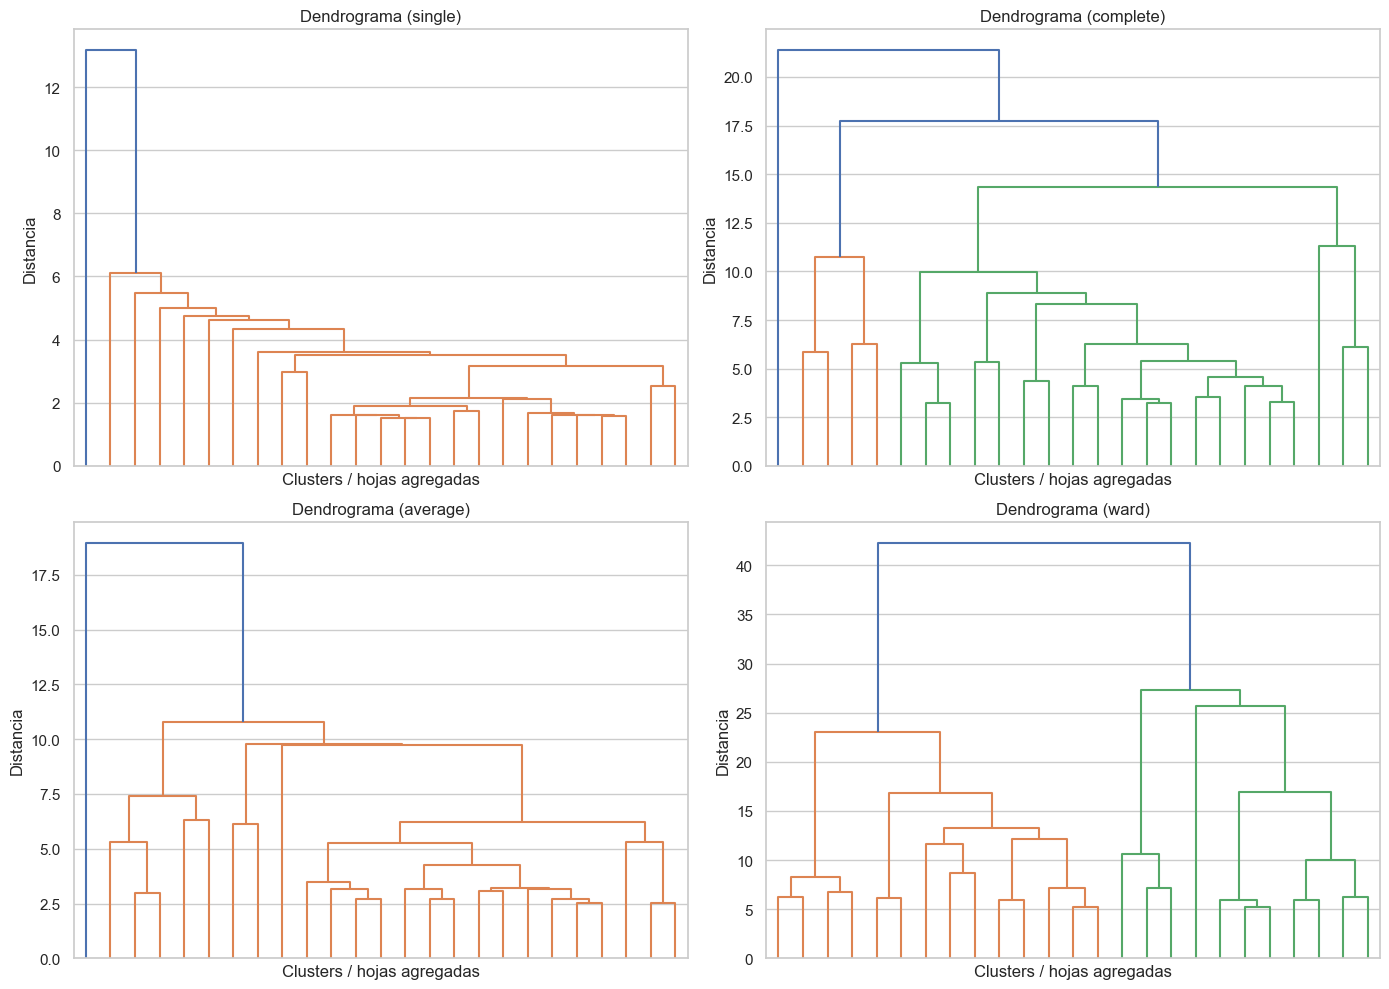

In [3]:
# Carga y preparación de Wholesale Customers
wholesale = fetch_ucirepo(id=292)
X_wh = wholesale.data.features.copy()

# Nos quedamos con columnas numéricas para clustering por distancia
X_wh_num = X_wh.select_dtypes(include=[np.number]).copy()

print('Shape original:', X_wh.shape)
print('Shape numérico para clustering:', X_wh_num.shape)

scaler_wh = StandardScaler()
X_wh_scaled = scaler_wh.fit_transform(X_wh_num)

linkage_methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(14, 10))
for i, method in enumerate(linkage_methods, 1):
    Z = linkage(X_wh_scaled, method=method, metric='euclidean')
    plt.subplot(2, 2, i)
    dendrogram(Z, truncate_mode='lastp', p=25, no_labels=True)
    plt.title(f'Dendrograma ({method})')
    plt.xlabel('Clusters / hojas agregadas')
    plt.ylabel('Distancia')

plt.tight_layout()
plt.show()

### Métricas internas de calidad de clusters

Para cada linkage y cada corte k calculo:

| Métrica | Qué responde | Cómo leerla |
|---------|--------------|-------------|
| Silhouette | ¿Cada punto está más cerca de su grupo que del vecino de otro grupo? | Entre −1 y 1; más alto = mejor (grupos bien separados). |
| Davies-Bouldin | ¿Los clusters están compactos y lejos entre sí? | Más bajo = mejor. |
| Calinski-Harabasz | ¿Hay mucha diferencia entre grupos respecto al interior? | Más alto = mejor. |

Combino estas tres con el dendrograma para elegir linkage y número de clusters k.

Después de las métricas, grafico los clusters en 2D (PCA y variables de gasto) para ver cómo se separan los grupos.


In [4]:
# Evaluación de cortes con métricas internas
k_values = [2, 3, 4, 5, 6]
rows = []

for method in linkage_methods:
    Z = linkage(X_wh_scaled, method=method, metric='euclidean')
    for k in k_values:
        labels = fcluster(Z, t=k, criterion='maxclust')
        n_clusters = len(np.unique(labels))

        # Evitar métricas inválidas si por alguna razón hay un solo cluster
        if n_clusters > 1:
            sil = silhouette_score(X_wh_scaled, labels)
            dbi = davies_bouldin_score(X_wh_scaled, labels)
            ch = calinski_harabasz_score(X_wh_scaled, labels)
        else:
            sil, dbi, ch = np.nan, np.nan, np.nan

        rows.append({
            'linkage': method,
            'k': k,
            'n_clusters': n_clusters,
            'silhouette': sil,
            'davies_bouldin': dbi,
            'calinski_harabasz': ch
        })

res_cluster = pd.DataFrame(rows)
res_cluster = res_cluster.sort_values(['k', 'silhouette'], ascending=[True, False])
res_cluster.head(20)

,linkage,k,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,single,2,2,0.845425,0.108639,56.707523
5,complete,2,2,0.845425,0.108639,56.707523
10,average,2,2,0.845425,0.108639,56.707523
15,ward,2,2,0.440629,1.092738,179.323599
1,single,3,3,0.769343,0.145137,42.746401
6,complete,3,3,0.735939,0.468221,80.314484
11,average,3,3,0.735939,0.468221,80.314484
16,ward,3,3,0.407084,1.075780,153.089616
7,complete,4,4,0.708502,0.719291,72.757017
12,average,4,4,0.707929,0.479992,70.460808


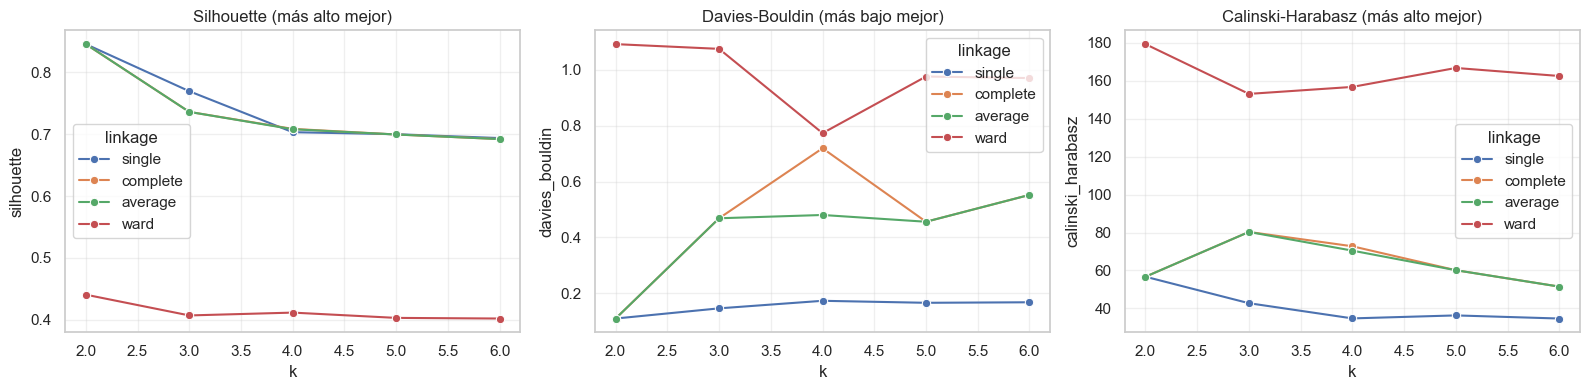

Mejor configuración por silhouette:
linkage                 single
k                            2
n_clusters                   2
silhouette            0.845425
davies_bouldin        0.108639
calinski_harabasz    56.707523
Name: 0, dtype: object


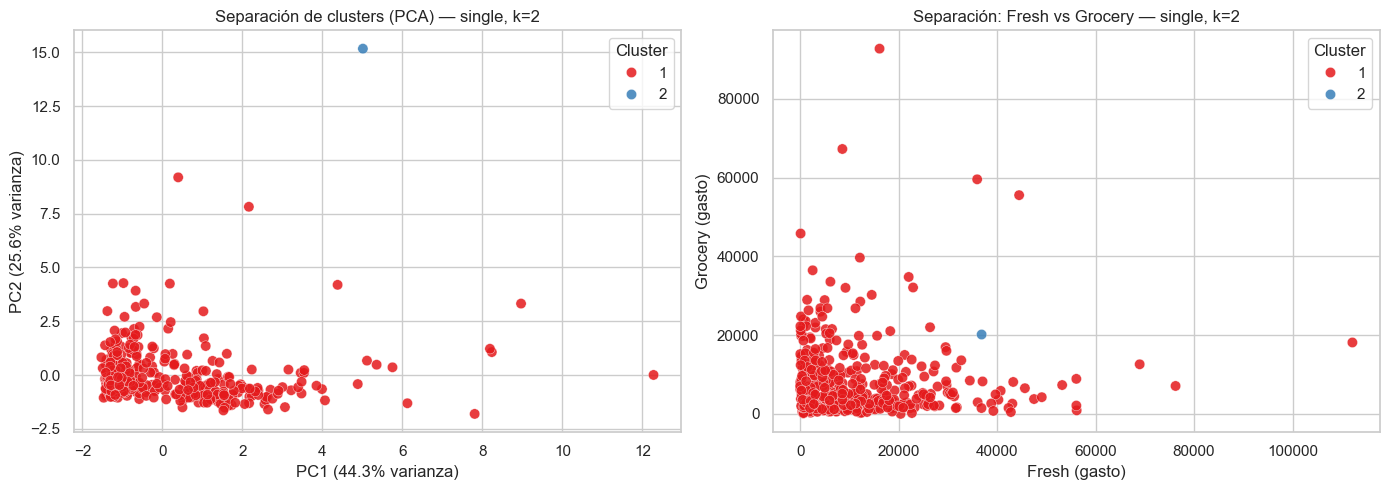

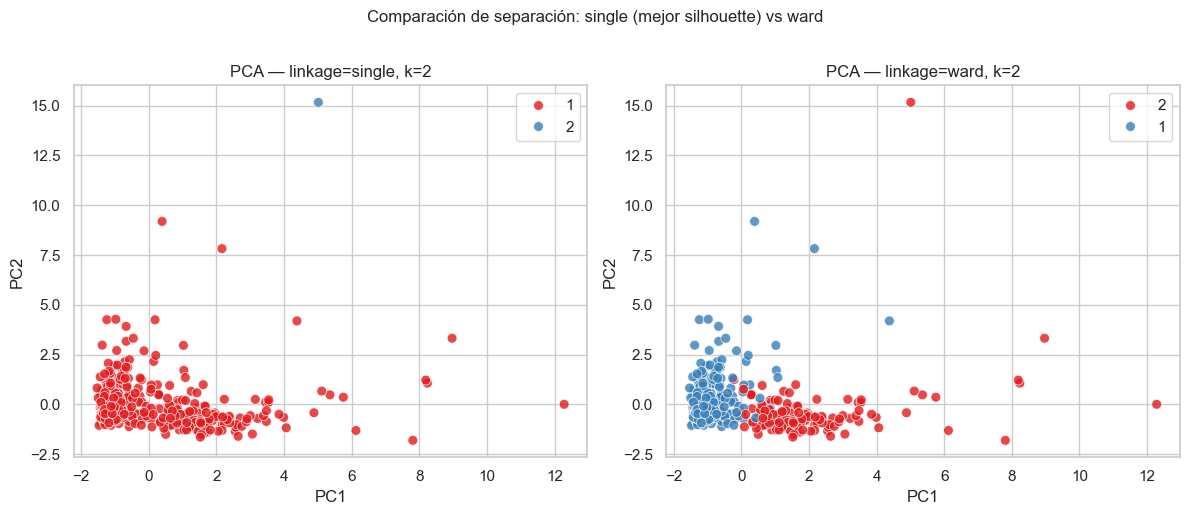

In [5]:
# Resumen visual para seleccionar linkage
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=res_cluster, x='k', y='silhouette', hue='linkage', marker='o', ax=axes[0])
axes[0].set_title('Silhouette (más alto mejor)')

sns.lineplot(data=res_cluster, x='k', y='davies_bouldin', hue='linkage', marker='o', ax=axes[1])
axes[1].set_title('Davies-Bouldin (más bajo mejor)')

sns.lineplot(data=res_cluster, x='k', y='calinski_harabasz', hue='linkage', marker='o', ax=axes[2])
axes[2].set_title('Calinski-Harabasz (más alto mejor)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mejor combinación por silhouette
best_row = res_cluster.loc[res_cluster['silhouette'].idxmax()]
print('Mejor configuración por silhouette:')
print(best_row)

# --- Visualización: separación de clusters en el plano ---
best_method = str(best_row['linkage'])
best_k = int(best_row['k'])
Z_best = linkage(X_wh_scaled, method=best_method, metric='euclidean')
labels_best = fcluster(Z_best, t=best_k, criterion='maxclust')

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_wh_scaled)

df_clust = X_wh_num.copy()
df_clust['cluster'] = labels_best.astype(str)
df_clust['PC1'] = X_pca[:, 0]
df_clust['PC2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_clust, x='PC1', y='PC2', hue='cluster',
    palette='Set1', ax=axes[0], s=55, alpha=0.85, edgecolor='w', linewidth=0.3
)
axes[0].set_title(f'Separación de clusters (PCA) — {best_method}, k={best_k}')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[0].legend(title='Cluster')

sns.scatterplot(
    data=df_clust, x='Fresh', y='Grocery', hue='cluster',
    palette='Set1', ax=axes[1], s=55, alpha=0.85, edgecolor='w', linewidth=0.3
)
axes[1].set_title(f'Separación: Fresh vs Grocery — {best_method}, k={best_k}')
axes[1].set_xlabel('Fresh (gasto)')
axes[1].set_ylabel('Grocery (gasto)')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

# Comparación visual: mejor linkage (single) vs ward con k=2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, method in zip(axes, ['single', 'ward']):
    Z_cmp = linkage(X_wh_scaled, method=method, metric='euclidean')
    lab = fcluster(Z_cmp, t=2, criterion='maxclust')
    X_p = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_wh_scaled)
    sns.scatterplot(x=X_p[:, 0], y=X_p[:, 1], hue=lab.astype(str),
                    palette='Set1', ax=ax, s=50, alpha=0.8, legend=True)
    ax.set_title(f'PCA — linkage={method}, k=2')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.suptitle('Comparación de separación: single (mejor silhouette) vs ward', y=1.02)
plt.tight_layout()
plt.show()

### Conclusión del Punto 2

Datos: Wholesale Customers, 440 clientes, 7 variables numéricas (gasto por categoría y canal).

Mejor configuración según métricas internas (silhouette y Davies-Bouldin)

| Configuración | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---------------|------------|----------------|-------------------|
| single / complete / average, k=2 | 0.845 | 0.109 | 56.71 |
| ward, k=2 | 0.441 | 1.093 | 179.32 |

- Con k = 2, single, complete y average dan el mismo corte (silhouette 0.845).
- Al subir k (3–6), el silhouette baja respecto a k=2; dos grupos resumen bien según esas métricas.
- Calinski-Harabasz favorece a ward (179 vs 57), así que las métricas no coinciden todas en el mismo linkage.

Qué muestran las gráficas (PCA y Fresh vs Grocery)

- Con single, k=2: casi todos los clientes van a un cluster y uno queda aislado (outlier de gasto). El silhouette alto se explica en parte porque ese punto está muy lejos del grupo mayoritario, no porque haya dos segmentos equilibrados de “gasto alto vs bajo”.
- Con ward, k=2: en PCA se aprecian dos nubes (masas izquierda y derecha), más útil para hablar de dos perfiles de clientes en el grueso de los datos.

Decisión

Reporto como mejor configuración por silhouette a single con k = 2 (equivalente a complete/average en este dataset). Reconozco que la inspección visual sugiere que ward con k = 2 describe mejor la separación de la mayoría de clientes, mientras que single destaca sobre todo un caso atípico.

Limitación

Las métricas son internas y sensibles al linkage; por eso combino tablas, dendrogramas y scatter antes de interpretar los grupos.

## Sustentación Punto 2

En este punto comparo clustering jerárquico con:

1. Preprocesamiento: resultados sin escalamiento vs con StandardScaler.
2. Linkages y cortes: al menos single y ward, con k = 2, 3, 4, 5, 6 y métricas (silhouette, Davies-Bouldin).
3. Gráficas: dendrogramas + PCA para ver separación; tablas para elegir k y linkage.


### Escalado vs sin escalado

La distancia euclidiana usa todas las columnas en la misma escala. Si una variable tiene valores mucho mayores (por ejemplo *Grocery* frente a *Delicassen*), domina el clustering sin escalar. Por eso se hace el mismo experimento con X_wh_num (crudo) y X_wh_scaled (estandarizado) para single y ward.



=== Silhouette: sin escalar vs estandarizado (mayor = mejor) ===


escala     Estandarizado  Sin escalar
linkage k                            
single  2          0.845        0.796
        3          0.769        0.726
        4          0.703        0.725
        5          0.700        0.718
        6          0.694        0.683
ward    2          0.441        0.345
        3          0.407        0.375
        4          0.412        0.348
        5          0.403        0.352
        6          0.402        0.314


=== Davies-Bouldin: sin escalar vs estandarizado (menor = mejor) ===


escala     Estandarizado  Sin escalar
linkage k                            
single  2          0.109        0.137
        3          0.145        0.172
        4          0.172        0.160
        5          0.165        0.163
        6          0.167        0.176
ward    2          1.093        1.197
        3          1.076        0.978
        4          0.773        0.970
        5          0.977        0.911
        6          0.971        1.007


Mejor por silhouette (Sin escalar): linkage=single, k=2, sil=0.796, DB=0.137

Mejor por silhouette (Estandarizado): linkage=single, k=2, sil=0.845, DB=0.109


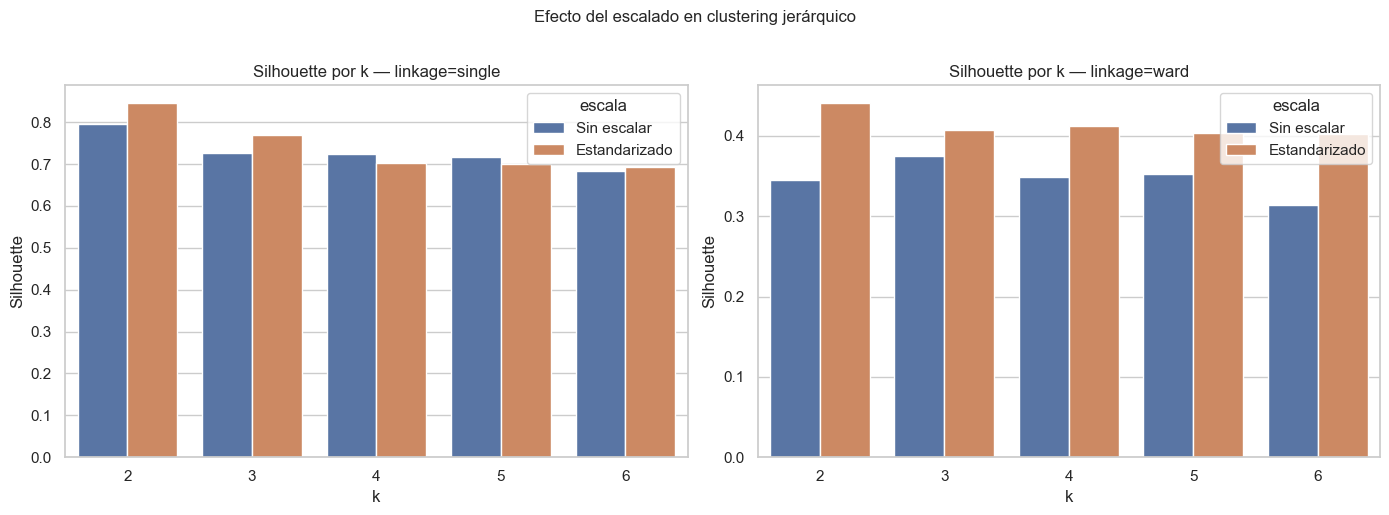

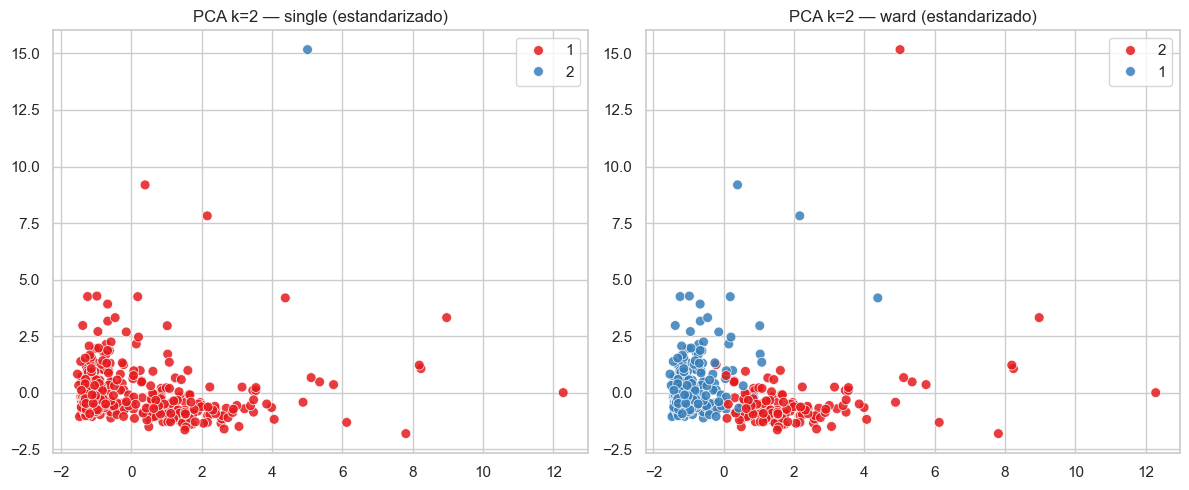

In [ ]:
# === Sustentación Punto 2: sin escalar vs estandarizado ===
from scipy.cluster.hierarchy import linkage, fcluster

def eval_cortes(X, nombre_escala, linkages, k_list):
    """Métricas por linkage y k para una matriz X."""
    rows = []
    X_arr = np.asarray(X, dtype=float)
    for method in linkages:
        Z = linkage(X_arr, method=method, metric='euclidean')
        for k in k_list:
            labels = fcluster(Z, t=k, criterion='maxclust')
            n_cl = len(np.unique(labels))
            if n_cl > 1:
                sil = silhouette_score(X_arr, labels)
                dbi = davies_bouldin_score(X_arr, labels)
            else:
                sil, dbi = np.nan, np.nan
            rows.append({
                'escala': nombre_escala,
                'linkage': method,
                'k': k,
                'n_clusters': n_cl,
                'silhouette': sil,
                'davies_bouldin': dbi,
            })
    return pd.DataFrame(rows)

k_sust = [2, 3, 4, 5, 6]
link_sust = ['single', 'ward']  

res_sin_escala = eval_cortes(X_wh_num.values, 'Sin escalar', link_sust, k_sust)
res_con_escala = eval_cortes(X_wh_scaled, 'Estandarizado', link_sust, k_sust)
res_escala_cmp = pd.concat([res_sin_escala, res_con_escala], ignore_index=True)

print('=== Silhouette: sin escalar vs estandarizado (mayor = mejor) ===')
tabla_sil = res_escala_cmp.pivot_table(
    index=['linkage', 'k'], columns='escala', values='silhouette'
).round(3)
display(tabla_sil)

print('\n=== Davies-Bouldin: sin escalar vs estandarizado (menor = mejor) ===')
tabla_dbi = res_escala_cmp.pivot_table(
    index=['linkage', 'k'], columns='escala', values='davies_bouldin'
).round(3)
display(tabla_dbi)

# Mejor (k, linkage) por escala según silhouette
for esc in ['Sin escalar', 'Estandarizado']:
    sub = res_escala_cmp[res_escala_cmp['escala'] == esc]
    best = sub.loc[sub['silhouette'].idxmax()]
    print(f"\nMejor por silhouette ({esc}): linkage={best['linkage']}, k={int(best['k'])}, "
          f"sil={best['silhouette']:.3f}, DB={best['davies_bouldin']:.3f}")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, link_sust):
    sns.barplot(
        data=res_escala_cmp[res_escala_cmp['linkage'] == method],
        x='k', y='silhouette', hue='escala', ax=ax
    )
    ax.set_title(f'Silhouette por k — linkage={method}')
    ax.set_ylabel('Silhouette')
plt.suptitle('Efecto del escalado en clustering jerárquico', y=1.02)
plt.tight_layout()
plt.show()

# PCA k=2: single vs ward 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, method in zip(axes, link_sust):
    Z = linkage(X_wh_scaled, method=method, metric='euclidean')
    lab = fcluster(Z, t=2, criterion='maxclust')
    X_p = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_wh_scaled)
    sns.scatterplot(x=X_p[:, 0], y=X_p[:, 1], hue=lab.astype(str),
                    palette='Set1', ax=ax, s=50, alpha=0.85)
    ax.set_title(f'PCA k=2 — {method} (estandarizado)')
plt.tight_layout()
plt.show()

---

### Respuestas sustentación Punto 2

1. ¿Por qué el clustering jerárquico es sensible al escalamiento?

 
Porque agrupa con distancia euclidiana, o sea que cada variable entra con su unidad original. En el caso de Wholesale, categorías como Grocery o Milk tienen magnitudes mayores que Delicassen; sin escalar el algoritmo se guía casi solo por esas columnas. Con StandardScaler, todas contribuyen en una escala comparable y cambian las fusiones del dendrograma y las métricas. En la tabla, al estandarizar sube el silhouette en los casos que reporté, por ejemplo single k=2 pasa de 0.796 a 0.845, y ward k=2 de 0.345 a 0.441. También mejora Davies-Bouldin en single k=2 (0.137 → 0.109). Eso confirma que sin escalar las variables con mayor magnitud distorsionan la distancia euclidiana.

2. ¿Puede el dendrograma sugerir un k distinto al de las métricas internas?
   
Sí. El dendrograma se lee con un corte en altura (¿dónde “corto” el árbol?). las métricas como silhouette se calculan después de fijar k. Puedo ver en el dendrograma que a cierta altura aparecen, por ejemplo, 2 o 3 grupos grandes, pero al probar k=3,4,5,6 el silhouette sigue bajando respecto a k=2 (p. ej. single estandarizado: 0.845 → 0.769 → 0.703…). A la vez, en PCA ward k=2 muestra dos nubes más claras para la mayoría de clientes, mientras single k=2 separa sobre todo un outlier — las métricas pueden coincidir en k=2 pero la lectura visual y de negocio no es la misma.

1. ¿Por qué no elegir solo por una métrica?

Porque cada métrica mide otra cosa, silhouette (cohesión/separación local), Davies-Bouldin (compactidad global), Calinski-Harabasz (varianza entre/ dentro). En los resultados, single gana en silhouette (0.845) pero ward gana en Calinski-Harabasz (179 vs 57). Además, un valor alto de silhouette puede deberse a un punto extremo (single k=2), no a dos segmentos de negocio equilibrados. Pienso que sobretodo hay que tener en cuenta las reglas de negocio para entender con un mejor contexto cuál es la mejor manera de clasificar

## Punto 3: Regresión comparativa

### Contexto (Real Estate Valuation, UCI id=477)

Datos de transacciones inmobiliarias en Taiwán. Se predice el precio por unidad de área (Y house price of unit area). Comparo K-NN, SVR y MLP con partición 80 % train / 20 % test.

### Métricas que reporto

| Métrica | Significado |
|---------|-------------|
| MAE | Error absoluto medio: desviación promedio respecto al precio real (misma unidad que *y*). |
| RMSE | Raíz del error cuadrático medio; penaliza más los errores grandes. La uso en GridSearchCV. |
| R² | Proporción de varianza del precio que explica el modelo (cercano a 1 en train, suele bajar en test). |
| Gap (RMSE test − train) | Si el error en train es mucho menor que en test, hay sobreajuste (memorización). |


### Modelos de regresión 

- K-NN Regressor: predice el precio promediando los k vecinos más cercanos (tras escalar variables).
- ε-SVR: busca una función suave con margen ε; hiperparámetros C y gamma controlan rigidez/flexibilidad (kernel RBF).
- MLPRegressor: red neuronal feedforward para relaciones no lineales.

En el código comparo MAE, RMSE y R² en train y test, y calculo el gap para hablar de sobreajuste.



In [84]:
# Carga de Real Estate
real_est = fetch_ucirepo(id=477)
X_re = real_est.data.features.copy()
y_re = real_est.data.targets.copy()

if isinstance(y_re, pd.DataFrame):
    y_re = y_re.iloc[:, 0]

# Eliminar ID si existe
if 'No' in X_re.columns:
    X_re = X_re.drop(columns=['No'])

print('Shape X:', X_re.shape)
print('Shape y:', y_re.shape)
print(X_re.head())

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_re, y_re, test_size=0.2, random_state=RANDOM_STATE
)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Shape X: (414, 6)
Shape y: (414,)
   X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  
0                               10     24.98298     121.54024  
1                                9     24.98034     121.53951  
2                                5     24.98746     121.54391  
3                                5     24.98746     121.54391  
4                                5     24.97937     121.54245  


### Ajuste de hiperparámetros en regresión

Aplico GridSearchCV con KFold para seleccionar hiperparámetros minimizando RMSE en validación cruzada (no en test). El conjunto de test lo reservo para la comparación final entre modelos y para discutir generalización y complejidad.

Al final grafico precio real vs predicho y residuos en test para ver visualmente el ajuste de cada modelo.


In [85]:
# Definir pipelines y grillas
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])
param_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])
param_svr = {
    'model__kernel': ['rbf'],
    'model__C': [1, 10, 50, 100],
    'model__epsilon': [0.01, 0.05, 0.1, 0.2],
    'model__gamma': ['scale', 'auto']
}

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=3000, random_state=RANDOM_STATE))
])
param_mlp = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [1e-3, 5e-3, 1e-2]
}

def tune_model(name, pipe, param_grid):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_reg,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        refit=True
    )
    gs.fit(X_train_r, y_train_r)
    print(f'[{name}] mejores params:', gs.best_params_)
    print(f'[{name}] mejor CV RMSE:', -gs.best_score_)
    return gs

In [86]:
# Ejecutar tuning y evaluar en test
gs_knn = tune_model('KNN', pipe_knn, param_knn)
gs_svr = tune_model('SVR', pipe_svr, param_svr)
gs_mlp = tune_model('MLP', pipe_mlp, param_mlp)

best_models = {
    'KNN': gs_knn.best_estimator_,
    'SVR': gs_svr.best_estimator_,
    'MLP': gs_mlp.best_estimator_
}

def eval_reg(model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    return {
        'MAE_train': mean_absolute_error(y_tr, pred_tr),
        'MAE_test': mean_absolute_error(y_te, pred_te),
        'MSE_train': mean_squared_error(y_tr, pred_tr),
        'MSE_test': mean_squared_error(y_te, pred_te),
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, pred_te)),
        'R2_train': r2_score(y_tr, pred_tr),
        'R2_test': r2_score(y_te, pred_te),
    }

rows = []
for name, model in best_models.items():
    met = eval_reg(model, X_train_r, y_train_r, X_test_r, y_test_r)
    met['Modelo'] = name
    rows.append(met)

res_reg = pd.DataFrame(rows).set_index('Modelo').sort_values('RMSE_test')
res_reg

[KNN] mejores params: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
[KNN] mejor CV RMSE: 8.075087313913034
[SVR] mejores params: {'model__C': 10, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
[SVR] mejor CV RMSE: 8.137159599283468
[MLP] mejores params: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': 0.001}
[MLP] mejor CV RMSE: 8.10834052207532


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
Modelo,,,,,,,,
KNN,0.126586,4.253071,0.449592,36.261417,0.670516,6.021745,0.997610,0.783849
MLP,4.604450,4.325027,50.303006,37.399932,7.092461,6.115548,0.732560,0.777063
SVR,4.318870,4.257067,56.140334,38.601732,7.492685,6.213029,0.701525,0.769899


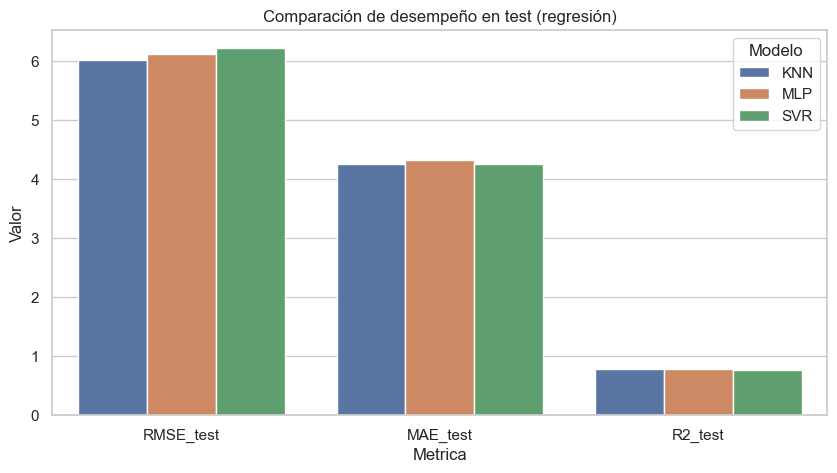

        RMSE_train  RMSE_test  Gap_RMSE_(test-train)  R2_train   R2_test
Modelo                                                                  
KNN       0.670516   6.021745               5.351229  0.997610  0.783849
MLP       7.092461   6.115548              -0.976913  0.732560  0.777063
SVR       7.492685   6.213029              -1.279656  0.701525  0.769899


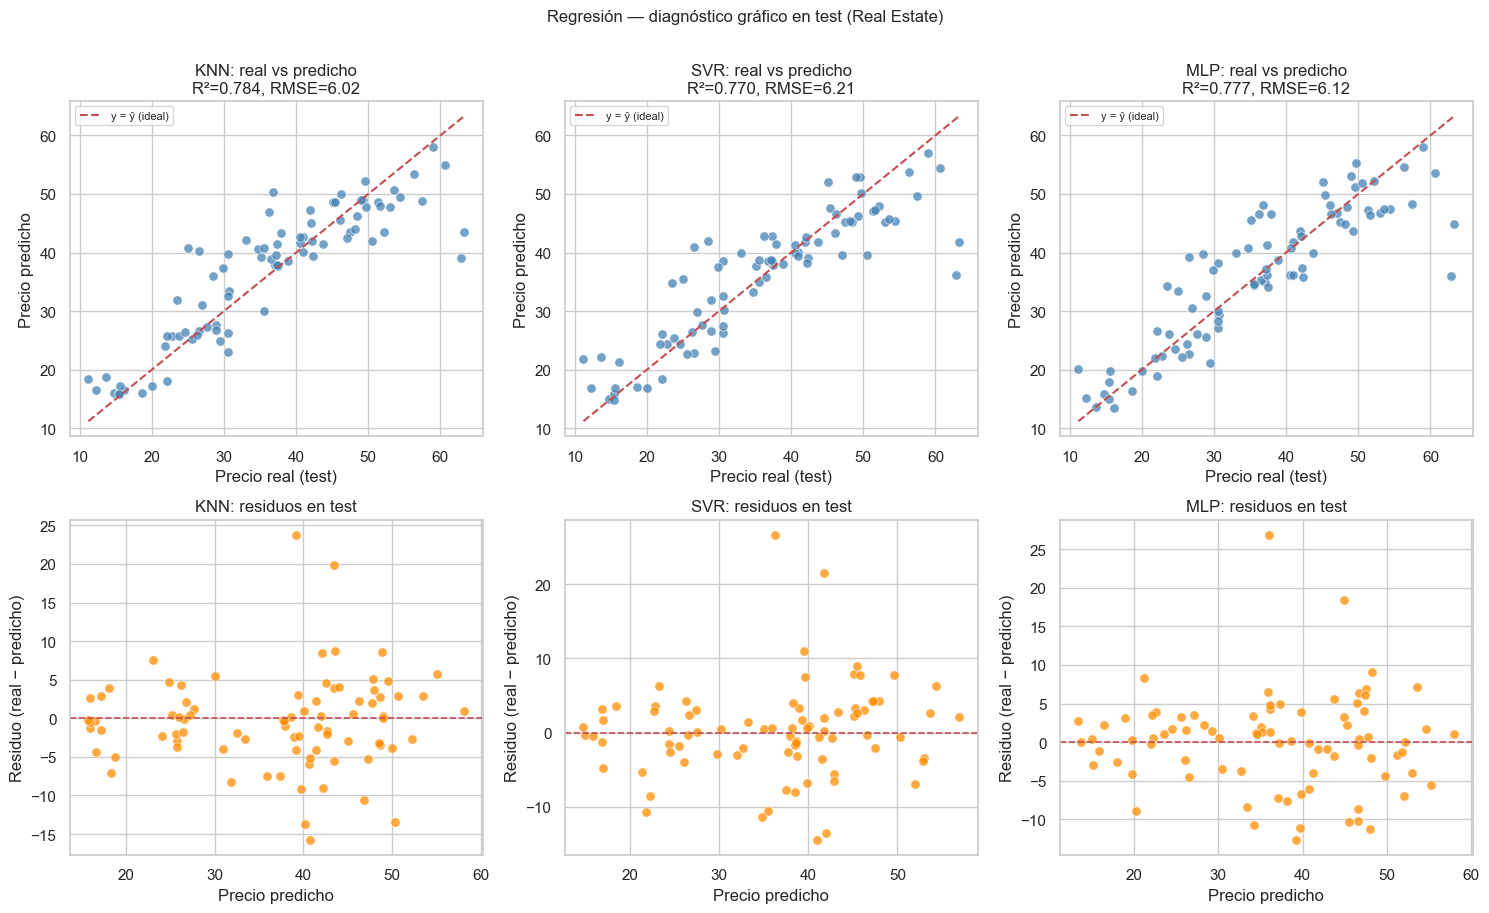

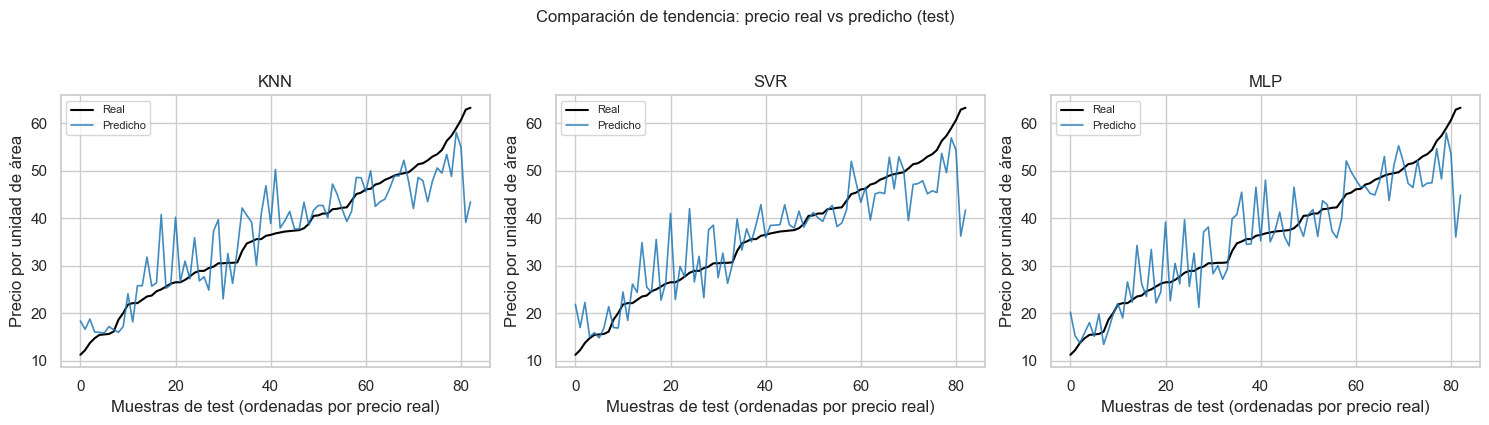

In [87]:
# Visualización de comparación final
plot_df = res_reg.reset_index().melt(
    id_vars='Modelo',
    value_vars=['RMSE_test', 'MAE_test', 'R2_test'],
    var_name='Metrica',
    value_name='Valor'
)

plt.figure(figsize=(10,5))
sns.barplot(data=plot_df, x='Metrica', y='Valor', hue='Modelo')
plt.title('Comparación de desempeño en test (regresión)')
plt.show()

# Diagnóstico rápido de over/underfitting con gap RMSE
res_reg['Gap_RMSE_(test-train)'] = res_reg['RMSE_test'] - res_reg['RMSE_train']
print(res_reg[['RMSE_train', 'RMSE_test', 'Gap_RMSE_(test-train)', 'R2_train', 'R2_test']])

# --- Gráficos: real vs predicho y residuos (conjunto de test) ---
y_te = np.asarray(y_test_r)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, (name, model) in enumerate(best_models.items()):
    pred_te = model.predict(X_test_r)
    ax_sc, ax_res = axes[0, col], axes[1, col]

    sns.scatterplot(x=y_te, y=pred_te, ax=ax_sc, alpha=0.75, s=45, color='steelblue')
    lo, hi = min(y_te.min(), pred_te.min()), max(y_te.max(), pred_te.max())
    ax_sc.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='y = ŷ (ideal)')
    ax_sc.set_xlabel('Precio real (test)')
    ax_sc.set_ylabel('Precio predicho')
    r2 = r2_score(y_te, pred_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred_te))
    ax_sc.set_title(f'{name}: real vs predicho\nR²={r2:.3f}, RMSE={rmse:.2f}')
    ax_sc.legend(fontsize=8)

    resid = y_te - pred_te
    sns.scatterplot(x=pred_te, y=resid, ax=ax_res, alpha=0.75, s=45, color='darkorange')
    ax_res.axhline(0, color='r', linestyle='--', lw=1.2)
    ax_res.set_xlabel('Precio predicho')
    ax_res.set_ylabel('Residuo (real − predicho)')
    ax_res.set_title(f'{name}: residuos en test')

plt.suptitle('Regresión — diagnóstico gráfico en test (Real Estate)', y=1.01)
plt.tight_layout()
plt.show()

# Curvas de predicción ordenadas (patrón global en test)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
idx_sort = np.argsort(y_te)
for ax, (name, model) in zip(axes, best_models.items()):
    pred_te = model.predict(X_test_r)[idx_sort]
    ax.plot(y_te[idx_sort], label='Real', color='black', lw=1.5)
    ax.plot(pred_te, label='Predicho', color='tab:blue', lw=1.2, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Muestras de test (ordenadas por precio real)')
    ax.set_ylabel('Precio por unidad de área')
    ax.legend(fontsize=8)
plt.suptitle('Comparación de tendencia: precio real vs predicho (test)', y=1.05)
plt.tight_layout()
plt.show()

### Conclusión del Punto 3

Datos: Real Estate Valuation, 414 muestras; objetivo: precio por unidad de área.

| Modelo | RMSE test | MAE test | R² test | RMSE train | Gap RMSE |
|--------|-----------|----------|---------|------------|----------|
| KNN | 6.02 | 4.25 | 0.784 | 0.67 | +5.35 |
| MLP | 6.12 | 4.33 | 0.777 | 7.09 | −0.98 |
| SVR | 6.21 | 4.26 | 0.770 | 7.49 | −1.28 |

Hiperparámetros elegidos (CV): KNN k=15, p=1, weights=distance; SVR C=10, ε=0.01, gamma=scale; MLP 32 neuronas, relu, alpha=0.01.

Interpretación

- KNN tiene el menor RMSE en test (6.02) y el mayor R² (0.78), pero RMSE train ≈ 0.67 → fuerte sobreajuste (memoriza vecinos).
- MLP y SVR tienen error de test similar (~6.1–6.2) y train/test más equilibrados (gap negativo en RMSE).
- En los gráficos real vs predicho, los tres modelos se acercan a la diagonal; KNN ajusta muy bien en train y se desvía más en test.
- En MLP apareció advertencia de no convergencia en algunos folds (3000 iteraciones).

Elección

Si priorizo menor error en test, elijo KNN; si priorizo estabilidad entre train y test, MLP o SVR son más razonables.

## Conclusiones finales

Punto 1 – CART: En Mushroom obtuve desempeño perfecto (holdout y CV = 1.0) con regla raíz en olor; en Car, accuracy 0.97 y F1 macro 0.95 con raíz en seguridad y un árbol más profundo (101 hojas). Validé con holdout y CV; la poda no fue necesaria.

Punto 2 – Clustering: Por silhouette, el mejor corte es k = 2 con single (0.845), pero las gráficas muestran que ese resultado separa sobre todo un outlier; ward con k = 2 muestra dos grupos más claros en la nube principal. Las métricas internas no siempre coinciden (Calinski-Harabasz favorece a ward).

Punto 3 – Regresión: KNN minimiza RMSE en test (6.02) con sobreajuste; MLP y SVR tienen error similar en test y mejor equilibrio train/test.

## Referencias

### Datasets UCI
- Mushroom: https://archive.ics.uci.edu/dataset/73/mushroom
- Car Evaluation: https://archive.ics.uci.edu/dataset/19/car+evaluation
- Wholesale Customers: https://archive.ics.uci.edu/dataset/292/wholesale+customers
- Real Estate Valuation: https://archive.ics.uci.edu/dataset/477/real-estate-valuation-data-set
- Repositorio UCI: https://archive.ics.uci.edu/

### Documentación
- scikit-learn – Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html
- scikit-learn – Decision Trees: https://scikit-learn.org/stable/modules/tree.html
- scikit-learn – Cost-complexity pruning: https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
- scikit-learn – SVR: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
- SciPy – hierarchical clustering: https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

### Bibliografía
- Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). Classification and Regression Trees.
- Bishop, C. M. (2006). Pattern Recognition and Machine Learning.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning.
- Ward, J. H. (1963). Hierarchical grouping to optimize an objective function.
- Cortes, C., & Vapnik, V. (1995). Support-vector networks.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning.
